In [1]:
from dataset import DexYCB
import smplx

layer_arg = {'create_global_orient': False, 'create_hand_pose': False, 'create_betas': False, 'create_transl': False}
mano = {'right': smplx.create("./smplx_models", 'mano', is_rhand=True, use_pca=False, flat_hand_mean=False, **layer_arg),
        'left': smplx.create("./smplx_models", 'mano', is_rhand=False, use_pca=False, flat_hand_mean=False, **layer_arg)}

/home/renkaiwen/.conda/envs/sl_vit/lib/python3.10/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


Fix shapedirs bug of MANO


In [21]:
dataset_test = DexYCB("s0", "test")

In [22]:
# len(dataset_test), dataset_test[10]

# 'color_file', 'depth_file', 'label_file', 'intrinsics', 'ycb_ids', 'ycb_grasp_ind', 'mano_side', 'mano_betas', 'is_bop_target', 'is_grasp_target'
item = dataset_test[399]
img_path = item['color_file']
label_path = item['label_file']

In [23]:
import einops as eps
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [7]:
import pickle as pkl
from scipy.sparse import csc_matrix

mano_data = {}
with open("./smplx_models/mano/MANO_RIGHT.pkl", "rb") as f:
    mano_data["right"] = pkl.load(f, encoding='latin1')
with open("./smplx_models/mano/MANO_LEFT.pkl", "rb") as f:
    mano_data["left"] = pkl.load(f, encoding='latin1')

/tmp/ipykernel_25002/44427674.py:6: DeprecationWarning: Please import `csc_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csc` namespace is deprecated and will be removed in SciPy 2.0.0.
  mano_data["right"] = pkl.load(f, encoding='latin1')
/tmp/ipykernel_25002/44427674.py:8: DeprecationWarning: Please import `csc_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csc` namespace is deprecated and will be removed in SciPy 2.0.0.
  mano_data["left"] = pkl.load(f, encoding='latin1')


In [24]:
label = np.load(label_path)  # seg, pose_y, pose_m, joint_3d, joint_2d
hand_comp = torch.from_numpy(mano_data[item['mano_side']]['hands_components'].astype(np.float32))

pose, transl = eps.unpack(label['pose_m'], [(48,), (3,)], "b *")
pose = torch.from_numpy(pose)
pose[:,3:] = pose[:,3:] @ hand_comp
transl = torch.from_numpy(transl)

shape = torch.tensor(item['mano_betas'])[None,:]

In [73]:
item['intrinsics']

{'fx': 613.0762329101562,
 'fy': 611.9989624023438,
 'ppx': 313.0279846191406,
 'ppy': 245.00865173339844}

In [25]:
output = mano[item['mano_side']](betas=shape,
                                 hand_pose=pose[:,3:],
                                 global_orient=pose[:,:3],
                                 transl=torch.zeros(1,3))

mesh = output.vertices[0]

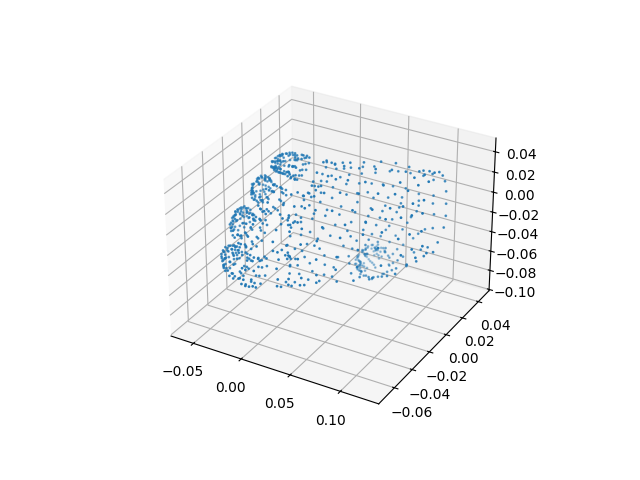

In [26]:
%matplotlib widget

plt.clf()
fig3d = plt.figure(0)
ax3d = fig3d.add_subplot(111, projection='3d')
ax3d.scatter(mesh[:,0],mesh[:,1],mesh[:,2], s=1)
plt.show()

In [69]:
from utils import crop_img
import torchvision.transforms as transforms
import kornia

image_preprocessing = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

x_min, x_max = float(label['joint_2d'][0,:,0].min()), float(label['joint_2d'][0,:,0].max())
y_min, y_max = float(label['joint_2d'][0,:,1].min()), float(label['joint_2d'][0,:,1].max())
bbox_center = ((x_min + x_max) / 2, (y_min + y_max) / 2)
bbox_size = ((x_max - x_min) * 1.2, (y_max - y_min) * 1.2)
img_tensor = image_preprocessing(img)
img_tensor = crop_img(img_tensor, bbox_center, bbox_size, squarify=True, avoid_zero=True)
# resize to 224*224
# img_tensor = kornia.geometry.transform.resize(img_tensor, (224, 224))

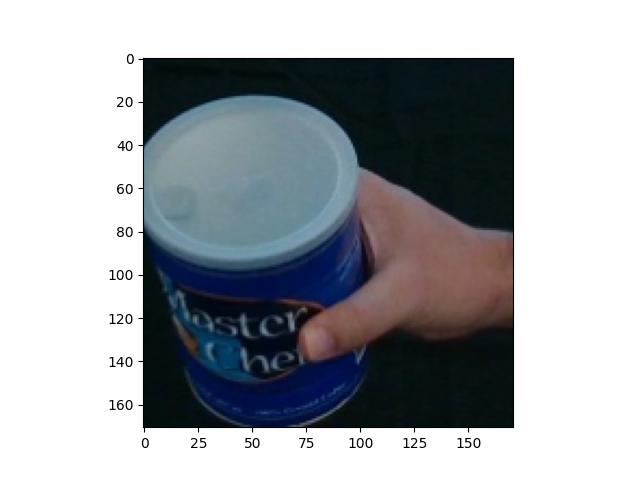

In [70]:
def unnormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    img = img * std[:,None,None] + mean[:,None,None]
    return img.permute(1,2,0)

plt.clf()
plt.imshow(unnormalize(img_tensor))
# plt.imshow(img)
# plt.scatter(label['joint_2d'][0,:,0],label['joint_2d'][0,:,1], c='r', s=2)
# plt.scatter([bbox_center[1]], [bbox_center[0]], c='y')
plt.show()

# Dataset

In [1]:
from dataset import DexYCB

/home/renkaiwen/.conda/envs/sl_vit/lib/python3.10/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


Fix shapedirs bug of MANO


In [10]:
dataset_test = DexYCB("s0", "test")
dataset_test.enforce_aug = True

(<matplotlib.image.AxesImage at 0x7f729041b7f0>, True)

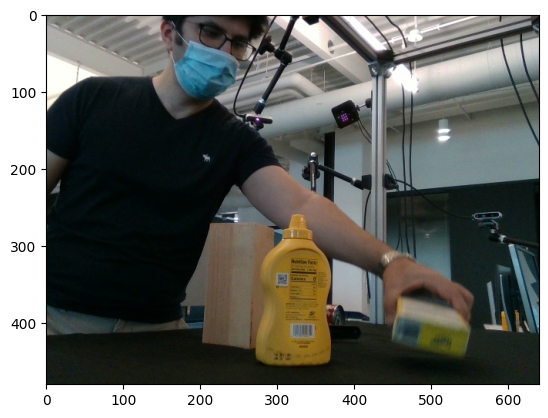

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

sample = dataset_test[1200]
img = cv2.cvtColor(cv2.imread(sample['image_path']), cv2.COLOR_BGR2RGB)
plt.imshow(img), sample['do_flip']

In [15]:
import torch
from utils import mano

pose = sample['pose'][None,:].clone()
shape = sample['shape'][None,:].clone()
transl = sample['transl'][None,:].clone()

output = \
mano.layer['right'](betas=shape,
                    hand_pose=pose[:,3:],
                    global_orient=pose[:,:3],
                    transl=transl)

In [8]:
all((pose == 0).tolist())

True

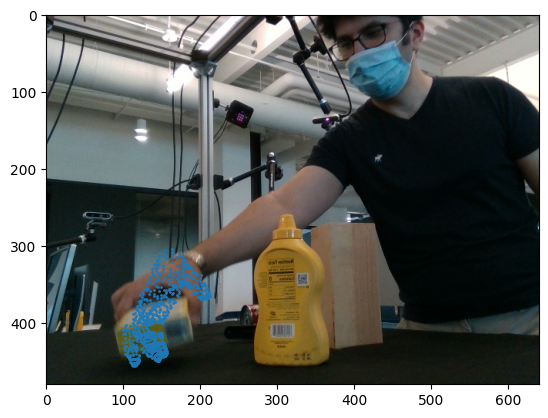

In [16]:
mesh = output.vertices[0]
intr = sample['intrinsics']
K = torch.tensor([
    [intr['fx'], 0, intr['ppx']],
    [0, intr['fy'], intr['ppy']],
    [0, 0, 1]
])

mesh2d = (K @ mesh.T).T
mesh2d = mesh2d[:,:-1] / mesh2d[:,-1:]

if sample['do_flip']:
    plt.imshow(img[:,::-1])
else:
    plt.imshow(img)
plt.scatter(mesh2d[:,0], mesh2d[:,1], s=1)

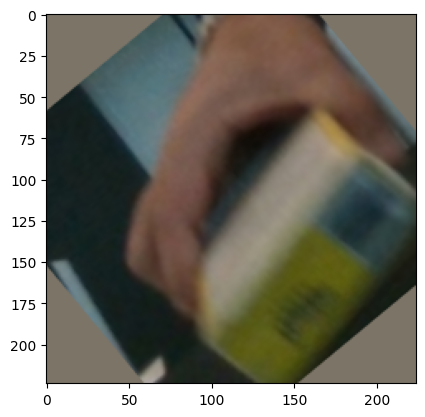

In [17]:
def unnormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    img = img * std[:,None,None] + mean[:,None,None]
    return img.permute(1,2,0)

plt.imshow(unnormalize(sample['image']))